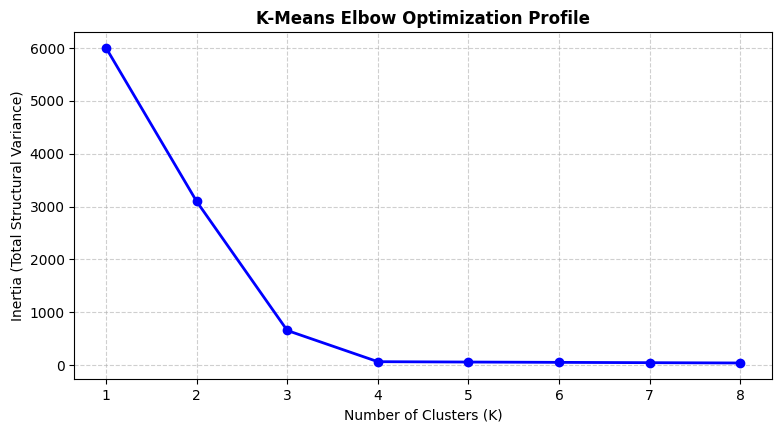

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

x,_ = make_blobs(
    n_samples=3000, 
    centers=4, 
    cluster_std=0.60, 
    random_state=42
)

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

inertia_Score=[]
k_range = range(1,9)

for k in k_range:
    kmeans_engine = KMeans(n_clusters=k,init='k-means++',n_init=10,random_state=42)
    kmeans_engine.fit(x_scaled)
    inertia_Score.append(kmeans_engine.inertia_)
    
plt.figure(figsize=(9, 4.5))
plt.plot(k_range, inertia_Score, marker='o', linestyle='-', color='b', linewidth=2)
plt.title("K-Means Elbow Optimization Profile", fontsize=12, fontweight='bold')
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia (Total Structural Variance)")
plt.xticks(k_range)
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

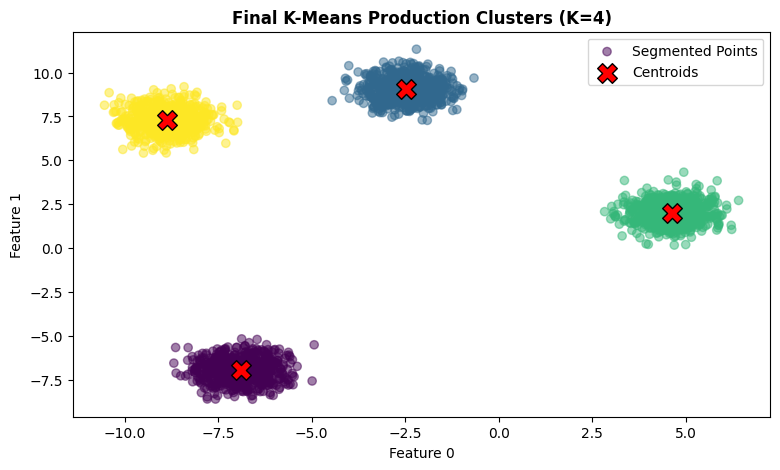

In [10]:
final_kmeans = KMeans(n_clusters=4, init="k-means++", n_init=10, random_state=42)
cluster_labels = final_kmeans.fit_predict(x_scaled)

plt.figure(figsize=(9, 5))
plt.scatter(x[:, 0], x[:, 1], c=cluster_labels, cmap='viridis', alpha=0.5, label="Segmented Points")

true_centroids = scaler.inverse_transform(final_kmeans.cluster_centers_)
plt.scatter(true_centroids[:, 0], true_centroids[:, 1], c='red', s=200, marker='X', edgecolor='black', label="Centroids")

plt.title("Final K-Means Production Clusters (K=4)", fontsize=12, fontweight='bold')
plt.xlabel("Feature 0")
plt.ylabel("Feature 1")
plt.legend()
plt.show()